| **BO3: Aligner les programmes éducatifs sur les besoins futurs du marché du travail** | Identifier les pays où certains métiers augmentent ou diminuent fortement clustering avec K_Means O DBSCAN | Clustering |  K-Means, HDBSCAN |

# **clusetering**

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [73]:
 
# Load engineered data for clustering
df_engineered = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\engineered_data.csv")
print(f"Engineered data loaded: {df_engineered.shape}")

# Load PCA data for clustering  
dataset_reduit = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\dataset_reduit.csv")

print(f"PCA data loaded: {dataset_reduit.shape}")

Engineered data loaded: (10000, 15)
PCA data loaded: (10000, 13)


In [74]:
print("\n Engineered Data:")
display(df_engineered.head(3))
print("\n PCA Data:")
display(dataset_reduit.head(3))
X_pca = dataset_reduit.values



 Engineered Data:


,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Location,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,Education_Level
0,research scientist (life sciences),finance,decreasing,moderate,121278.59,0.0,67.12,30.65,canada,30.01,20.339679,growth,90628.59,10.077720,4
1,tefl teacher,entertainment,increasing,moderate,118944.32,9.0,47.11,74.05,usa,58.02,1405.600000,growth,44894.32,39.165045,1
2,"editor, magazine features",entertainment,increasing,low,95884.27,15.0,14.18,47.36,india,34.39,42.168675,growth,48524.27,40.644352,4



 PCA Data:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Job_Title,AI_Impact_Level,Industry,Location
0,1.755449,0.183078,-0.196943,0.464800,0.788649,-1.674662,0.354047,0.922805,-0.976561,research scientist (life sciences),moderate,finance,canada
1,-0.506084,0.888199,-0.735315,-0.341181,0.276234,-1.391550,1.938440,-2.015683,1.505567,tefl teacher,moderate,entertainment,usa
2,-0.495815,1.144354,-0.539783,0.878884,-1.073024,-0.922933,-0.421771,0.070812,-0.331021,"editor, magazine features",low,entertainment,india


# **KMeans  dataset engineered**

In [75]:
# Select features relevant for BO3 clustering
country_features = [
    'Job_Growth_Rate_%',   
    'Median_Salary_USD',        
    'Automation_Risk_%',          
    'Remote_Work_Ratio_%'  
    
 ]
print(f"Using BO3-relevant features: {country_features}")
X_country = df_engineered[country_features].copy()

scaler = StandardScaler()
X_country_scaled = scaler.fit_transform(X_country)
print(f"Clustering data shape: {X_country_scaled.shape}")

Using BO3-relevant features: ['Job_Growth_Rate_%', 'Median_Salary_USD', 'Automation_Risk_%', 'Remote_Work_Ratio_%']
Clustering data shape: (10000, 4)


In [76]:
K_range = range(2, 15)
inertia = []
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_country_scaled)
    inertia.append(kmeans.inertia_)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_country_scaled)
    score = silhouette_score(X_country_scaled, labels)
    sil_scores.append(score)

optimal_k = K_range[np.argmax(sil_scores)]
print(f"Optimal k determined by silhouette score: {optimal_k}")

Optimal k determined by silhouette score: 7


In [77]:
print("\nSilhouette Scores:")
for k, score in zip(K_range, sil_scores):
    print(f"k={k}: {score:.3f}")

kmeans_optimized = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_engineered['KMeans_Cluster'] = kmeans_optimized.fit_predict(X_country_scaled)

print(f"\nClustering applied with k={optimal_k}")
cluster_distribution = df_engineered['KMeans_Cluster'].value_counts().sort_index()
print("Distribution des clusters KMeans:")
print(cluster_distribution)


Silhouette Scores:
k=2: 0.218
k=3: 0.211
k=4: 0.227
k=5: 0.249
k=6: 0.244
k=7: 0.259
k=8: 0.254
k=9: 0.257
k=10: 0.257
k=11: 0.255
k=12: 0.244
k=13: 0.239
k=14: 0.235

Clustering applied with k=7
Distribution des clusters KMeans:
KMeans_Cluster
0    1681
1    1707
2    1626
3    1609
4     213
5    1559
6    1605
Name: count, dtype: int64


**Elbow Method**

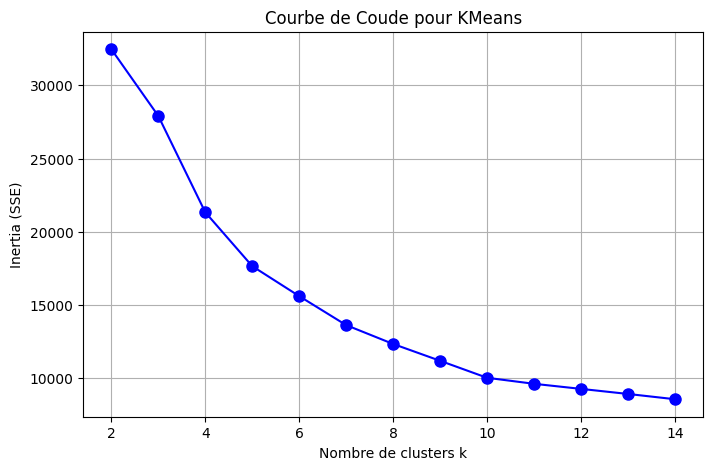

In [78]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertia (SSE)")
plt.title("Courbe de Coude pour KMeans")
plt.grid(True)
plt.show()

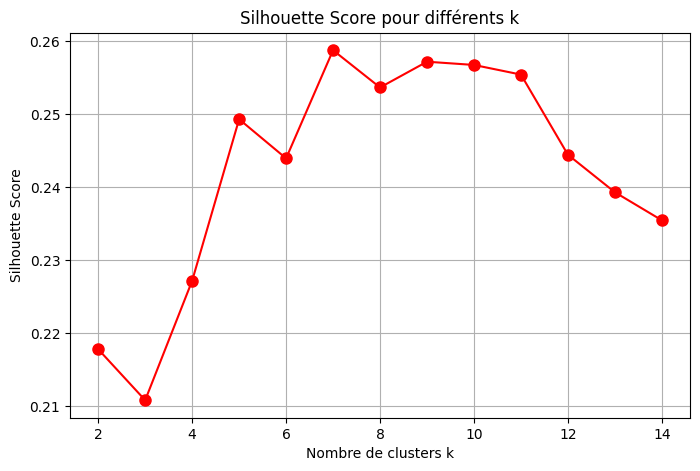

In [79]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, 'ro-', markersize=8)
plt.xlabel("Nombre de clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score pour différents k")
plt.grid(True)
plt.show()

**VISUALISATION DES CLUSTERS**

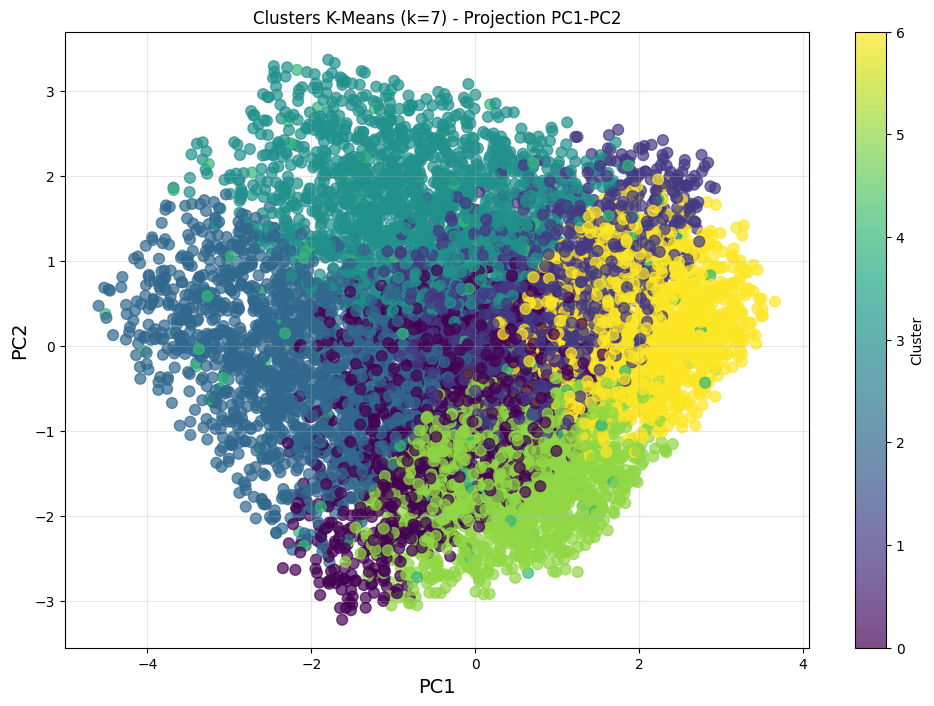

In [80]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df_engineered['KMeans_Cluster'].values, 
                     cmap='viridis', alpha=0.7, s=60)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title(f'Clusters K-Means (k={optimal_k}) - Projection PC1-PC2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
for country in df_engineered['Location'].unique():
    print(f"=== {country} ===")
    for cluster in df_engineered['KMeans_Cluster'].unique():
        subset = df_engineered[(df_engineered['Location'] == country) & (df_engineered['KMeans_Cluster'] == cluster)]
        if len(subset) == 0:
            continue
        # Top 5 métiers du cluster
        top_jobs = [str(job) for job in subset['Job_Title'].value_counts().head(5).index.tolist()]
        # Moyennes des indicateurs
        mean_growth = subset['Job_Growth_Rate_%'].mean().round(2)
        mean_salary = subset['Median_Salary_USD'].mean().round(2)
        mean_risk = subset['Automation_Risk_%'].mean().round(2)
        
        print(f"Cluster {cluster}:")
        print(f"  Croissance moyenne : {mean_growth}%")
        print(f"  Salaire moyen : {mean_salary} USD")
        print(f"  Risque d'automatisation : {mean_risk}%")
        print(f"  Métiers principaux : {', '.join(top_jobs)}")


=== canada ===
Cluster 6:
  Croissance moyenne : 82.93%
  Salaire moyen : 120101.84 USD
  Risque d'automatisation : 26.83%
  Métiers principaux : farm manager, advertising account planner, animator, restaurant manager, maintenance engineer
Cluster 3:
  Croissance moyenne : 74.02%
  Salaire moyen : 121502.15 USD
  Risque d'automatisation : 70.01%
  Métiers principaux : education officer, museum, librarian, public, press sub, chartered certified accountant, medical sales representative
Cluster 1:
  Croissance moyenne : 86.97%
  Salaire moyen : 86448.81 USD
  Risque d'automatisation : 22.0%
  Métiers principaux : estate agent, private music teacher, equality and diversity officer, museum/gallery exhibitions officer, occupational therapist
Cluster 0:
  Croissance moyenne : 64.62%
  Salaire moyen : 100489.0 USD
  Risque d'automatisation : 77.56%
  Métiers principaux : facilities manager, surgeon, public affairs consultant, visual merchandiser, retail manager
Cluster 2:
  Croissance moyenne 

In [82]:
# Cluster characteristics
print(f"\n CARACTÉRISTIQUES DES {optimal_k} CLUSTERS:")
cluster_profiles = []
for cluster in sorted(df_engineered['KMeans_Cluster'].unique()):
    cluster_data = df_engineered[df_engineered['KMeans_Cluster'] == cluster]
    
    growth = cluster_data['Job_Growth_Rate_%'].mean().round(2)
    salary = cluster_data['Median_Salary_USD'].mean().round(2)
    risk = cluster_data['Automation_Risk_%'].mean().round(2)
    count = len(cluster_data)
    top_jobs = cluster_data['Job_Title'].value_counts().head(3).index.tolist()
    
    if growth > 10:
        cluster_type = " FORTE CROISSANCE"
    elif growth < -5:
        cluster_type = " FORT DÉCLIN" 
    elif growth > 0:
        cluster_type = "↗ CROISSANCE MODÉRÉE"
    else:
        cluster_type = " STABLE"
    
    cluster_profiles.append({
        'cluster': cluster, 'growth': growth, 'salary': salary, 
        'risk': risk, 'count': count, 'top_jobs': top_jobs, 'type': cluster_type
    })
    
    print(f"\n{cluster_type} - Cluster {cluster}:")
    print(f"   Croissance: {growth}%")
    print(f"   Salaire moyen: {salary} USD")
    print(f"   Risque automation: {risk}%")
    print(f"   {count} métiers")
    print(f"    Métiers: {', '.join(top_jobs)}")



 CARACTÉRISTIQUES DES 7 CLUSTERS:

 FORTE CROISSANCE - Cluster 0:
   Croissance: 75.27%
   Salaire moyen: 96651.21 USD
   Risque automation: 78.74%
   1681 métiers
    Métiers: conservator, museum/gallery, surveyor, insurance, osteopath

 FORTE CROISSANCE - Cluster 1:
   Croissance: 81.84%
   Salaire moyen: 88061.76 USD
   Risque automation: 21.46%
   1707 métiers
    Métiers: occupational therapist, office manager, personal assistant

 FORTE CROISSANCE - Cluster 2:
   Croissance: 80.19%
   Salaire moyen: 56501.19 USD
   Risque automation: 73.29%
   1626 métiers
    Métiers: speech and language therapist, physiological scientist, designer, textile

 FORTE CROISSANCE - Cluster 3:
   Croissance: 78.68%
   Salaire moyen: 122441.86 USD
   Risque automation: 69.8%
   1609 métiers
    Métiers: audiological scientist, psychotherapist, english as a second language teacher

 FORTE CROISSANCE - Cluster 4:
   Croissance: 3399.38%
   Salaire moyen: 88916.73 USD
   Risque automation: 49.39%
   213

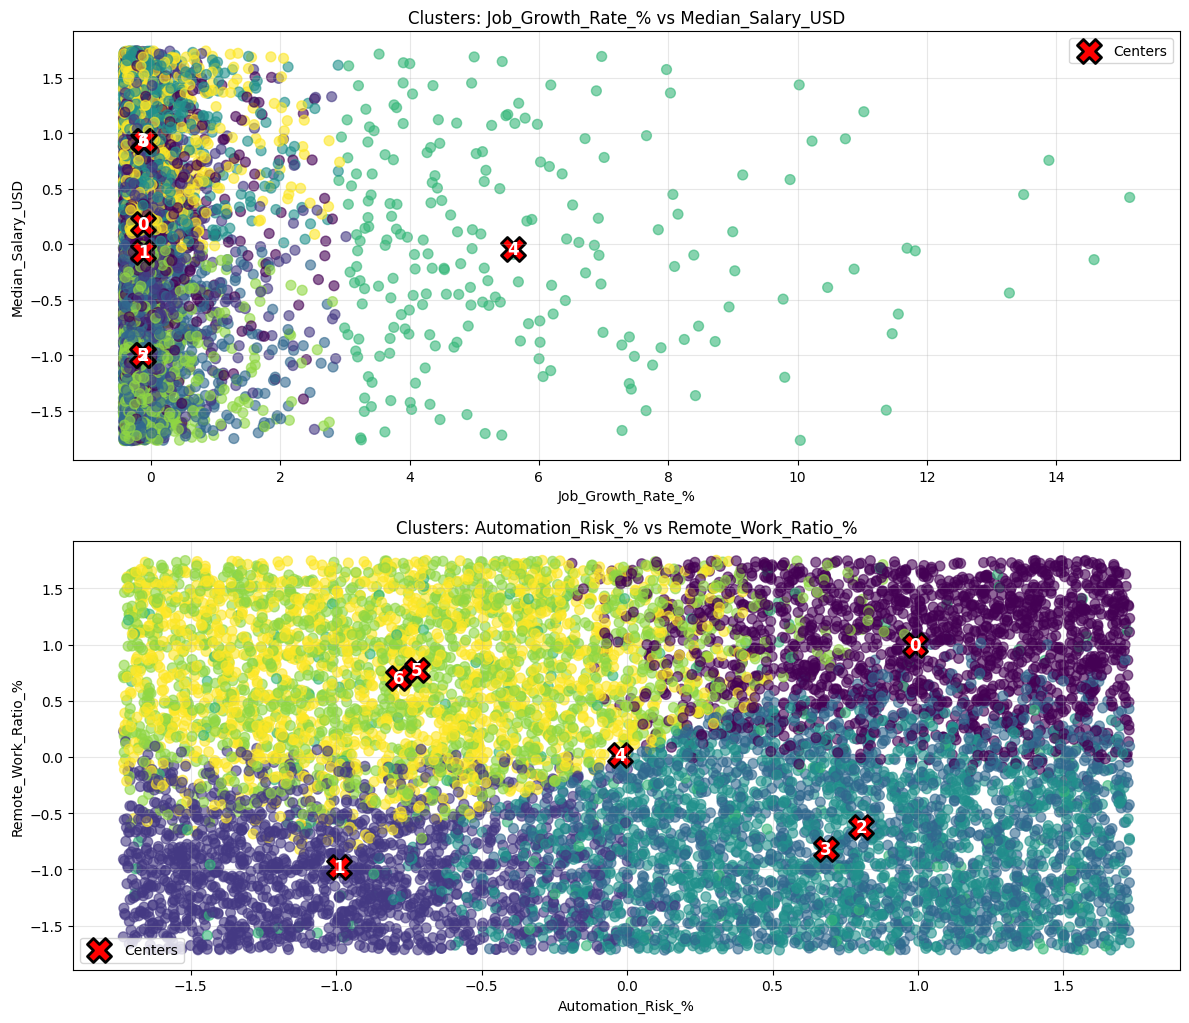

In [83]:
X = X_country_scaled
labels = df_engineered['KMeans_Cluster'].values
centers = kmeans_optimized.cluster_centers_
features = country_features
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
# Plot 1: Feature 0 vs Feature 1
axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
axes[0].scatter(centers[:, 0], centers[:, 1], c='red', s=300, marker='X', 
               edgecolors='black', linewidth=2, label='Centers')
for i, center in enumerate(centers):
    axes[0].text(center[0], center[1], str(i), fontsize=12, fontweight='bold', 
                color='white', ha='center', va='center')
axes[0].set_xlabel(features[0])
axes[0].set_ylabel(features[1])
axes[0].set_title(f'Clusters: {features[0]} vs {features[1]}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Plot 2: Feature 2 vs Feature 3  
axes[1].scatter(X[:, 2], X[:, 3], c=labels, cmap='viridis', alpha=0.6, s=50)
axes[1].scatter(centers[:, 2], centers[:, 3], c='red', s=300, marker='X',
               edgecolors='black', linewidth=2, label='Centers')
for i, center in enumerate(centers):
    axes[1].text(center[2], center[3], str(i), fontsize=12, fontweight='bold',
                color='white', ha='center', va='center')
axes[1].set_xlabel(features[2])
axes[1].set_ylabel(features[3])
axes[1].set_title(f'Clusters: {features[2]} vs {features[3]}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Plot 3: Feature 4 vs Feature 5
if X.shape[1] >= 6:  # Check if we have at least 6 features
    axes[2].scatter(X[:, 4], X[:, 5], c=labels, cmap='viridis', alpha=0.6, s=50)
    axes[2].scatter(centers[:, 4], centers[:, 5], c='red', s=300, marker='X',
                   edgecolors='black', linewidth=2, label='Centers')
    for i, center in enumerate(centers):
        axes[2].text(center[4], center[5], str(i), fontsize=12, fontweight='bold',
                    color='white', ha='center', va='center')
    axes[2].set_xlabel(features[4])
    axes[2].set_ylabel(features[5])
    axes[2].set_title(f'Clusters: {features[4]} vs {features[5]}')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].set_visible(False) 

plt.tight_layout()
plt.show()

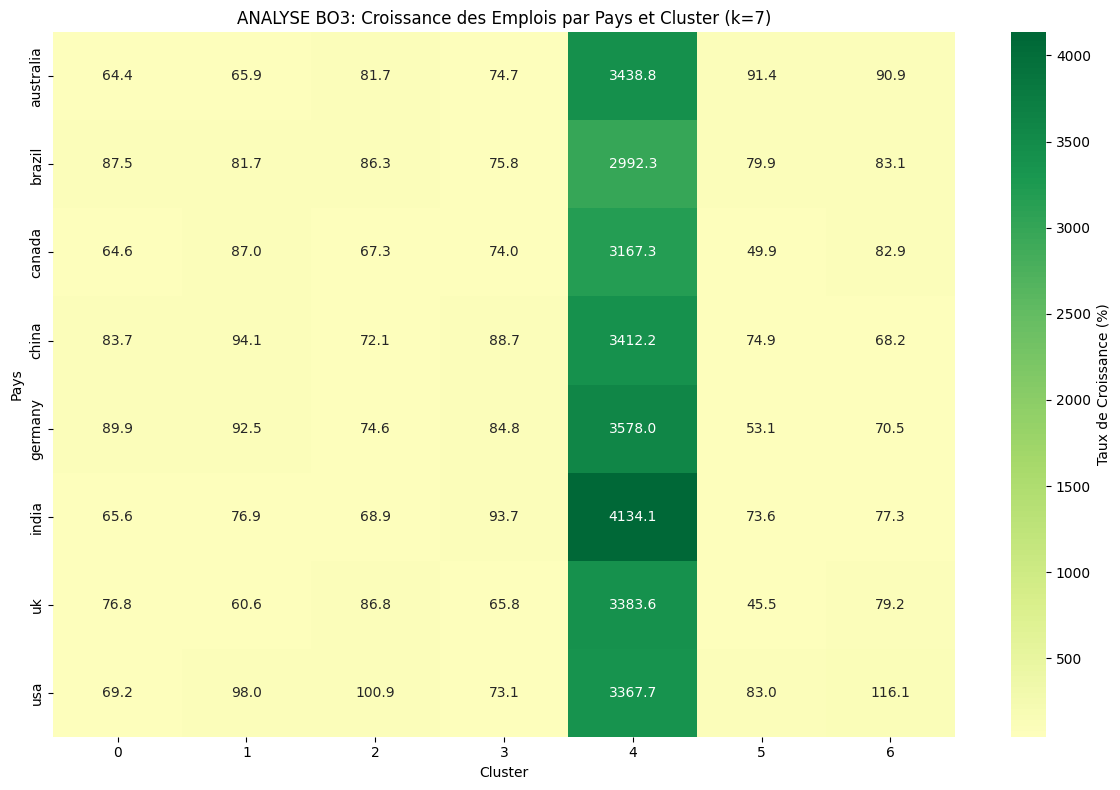

In [84]:
plt.figure(figsize=(12, 8))
growth_pivot = df_engineered.pivot_table(
    values='Job_Growth_Rate_%', 
    index='Location', 
    columns='KMeans_Cluster', 
    aggfunc='mean'
)
sns.heatmap(growth_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            cbar_kws={'label': 'Taux de Croissance (%)'})
plt.title(f'ANALYSE BO3: Croissance des Emplois par Pays et Cluster (k={optimal_k})')
plt.xlabel('Cluster')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

# **DBSCAN**

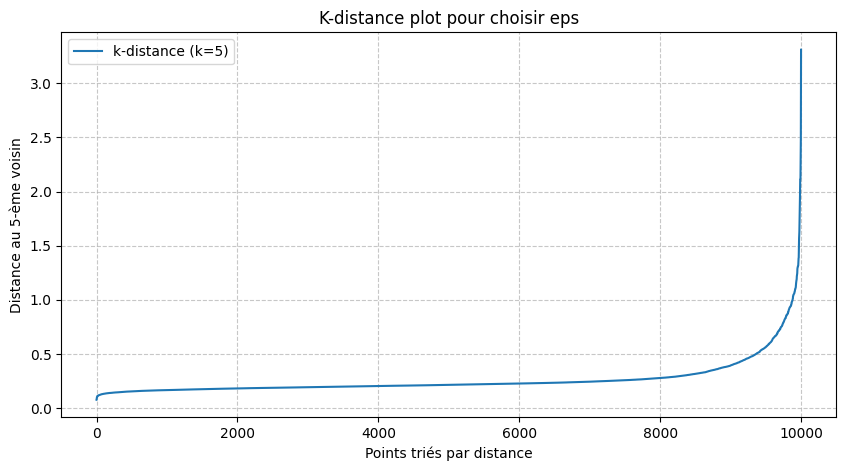

In [88]:
df = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\prepared_data.csv")

# ==============================
# 2. Features sélectionnées
# ==============================
features = ['Job_Growth_Rate_%', 'Median_Salary_USD', 'Automation_Risk_%', 'Remote_Work_Ratio_%']
X = df[features].values

# ==============================
# 3. minPts = D + 1
# ==============================
D = X.shape[1]
minPts = D + 1

# ==============================
# 4. K-distance plot pour choisir eps
# ==============================
neighbors = NearestNeighbors(n_neighbors=minPts).fit(X)
distances, _ = neighbors.kneighbors(X)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10,5))
plt.plot(k_distances, label=f"k-distance (k={minPts})")
plt.title("K-distance plot pour choisir eps")
plt.xlabel("Points triés par distance")
plt.ylabel(f"Distance au {minPts}-ème voisin")
plt.grid(True, linestyle="--", alpha=0.7)

# Ligne horizontale pour eps choisi (à ajuster après observation du plot)
eps_chosen = 0.5 # <-- ajuster selon le coude de ta courbe
plt.legend()
plt.show()

# ==============================
# 5. Application DBSCAN
# ==============================
dbscan = DBSCAN(eps=eps_chosen, min_samples=minPts)
labels = dbscan.fit_predict(X)
df['DBSCAN_Cluster'] = labels

# ==============================

EPS (knee method) = 0.4803


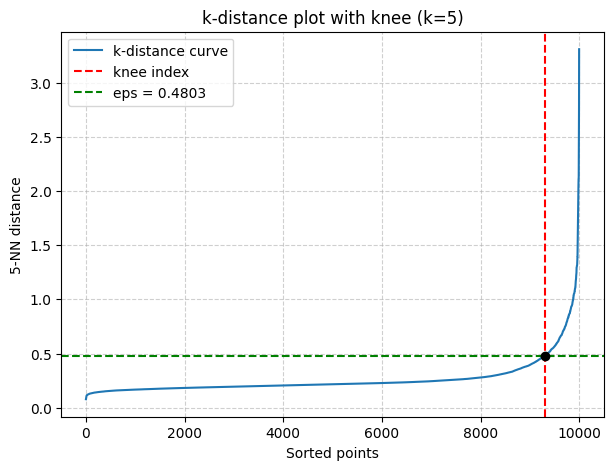

Clusters = 6
Bruit = 527 (5.3%)
Labels uniques = [-1  0  1  2  3  4  5]


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------
# 1) k-distance computation
# --------------------------
D = X.shape[1]
minPts = D + 1

nbrs = NearestNeighbors(n_neighbors=minPts).fit(X)
k_dists, _ = nbrs.kneighbors(X)

k_dists = np.sort(k_dists[:, -1])
n = len(k_dists)

# --------------------------
# 2) Knee (max curvature)
# --------------------------
# points defining the line
x_all = np.arange(n)
p1 = np.array([0, k_dists[0]])
p2 = np.array([n-1, k_dists[-1]])

# distance from each point to line p1-p2
distances = []
for i in range(n):
    p = np.array([x_all[i], k_dists[i]])
    # perpendicular distance formula in 2D
    num = np.abs((p2[1]-p1[1])*p[0] - (p2[0]-p1[0])*p[1] + p2[0]*p1[1] - p2[1]*p1[0])
    den = np.sqrt((p2[1]-p1[1])**2 + (p2[0]-p1[0])**2)
    distances.append(num/den)

knee_index = np.argmax(distances)
eps_knee = k_dists[knee_index]

print(f"EPS (knee method) = {eps_knee:.4f}")

# --------------------------
# 3) Plot with straight line
# --------------------------
plt.figure(figsize=(7,5))
plt.plot(k_dists, label="k-distance curve")

# vertical line (x = knee)
plt.axvline(x=knee_index, color="red", linestyle="--", label="knee index")

# horizontal line (y = eps)
plt.axhline(y=eps_knee, color="green", linestyle="--", label=f"eps = {eps_knee:.4f}")

plt.scatter(knee_index, eps_knee, color="black", zorder=5)

plt.title(f"k-distance plot with knee (k={minPts})")
plt.xlabel("Sorted points")
plt.ylabel(f"{minPts}-NN distance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


# 4) DBSCAN final
dbscan = DBSCAN(eps=eps_knee, min_samples=minPts)
labels = dbscan.fit_predict(X)

df_engineered["DBSCAN_Cluster"] = labels

unique_labels = np.unique(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

print(f"Clusters = {n_clusters}")
print(f"Bruit = {n_noise} ({100*n_noise/len(labels):.1f}%)")
print(f"Labels uniques = {unique_labels}")

In [90]:
cluster_summary = []

for cluster in sorted(df['DBSCAN_Cluster'].unique()):
    cluster_df = df[df['DBSCAN_Cluster'] == cluster]
    n_jobs = len(cluster_df)
    growth_mean = cluster_df['Job_Growth_Rate_%'].mean()
    salary_mean = cluster_df['Median_Salary_USD'].mean()
    risk_mean = cluster_df['Automation_Risk_%'].mean()
    remote_mean = cluster_df['Remote_Work_Ratio_%'].mean()
    
    # Conversion en str pour éviter les erreurs
    top_jobs = ", ".join(cluster_df['Job_Title'].head(5).astype(str).tolist())
    top_countries = ", ".join(cluster_df['Location'].head(3).astype(str).tolist())
    
    cluster_summary.append({
        "Cluster": cluster,
        "N_jobs": n_jobs,
        "Growth_mean_%": growth_mean,
        "Salary_mean_USD": salary_mean,
        "Automation_Risk_%": risk_mean,
        "Remote_Work_mean_%": remote_mean,
        "Top_jobs": top_jobs,
        "Top_countries": top_countries
    })

summary_df = pd.DataFrame(cluster_summary)
summary_df.sort_values(by="Cluster", inplace=True)
summary_df

,Cluster,N_jobs,Growth_mean_%,Salary_mean_USD,Automation_Risk_%,Remote_Work_mean_%,Top_jobs,Top_countries
0,-1,492,3.407266,-0.033740,-0.044245,0.060950,"tefl teacher, midwife, lawyer, general practic...","1.5328700592518645, 1.5328700592518645, -0.640..."
1,0,9483,-0.180602,0.001714,0.002474,-0.003060,"research scientist (life sciences), editor, ma...","-0.6404888791457882, 0.6635264838928032, -0.20..."
2,1,5,1.698498,-1.435872,1.091614,-1.421626,"conference centre manager, economist, clinical...","0.6635264838928032, 0.2288546962132727, -1.509..."
3,2,5,1.588565,1.351695,1.033703,0.957307,"advertising account executive, osteopath, inte...","0.6635264838928032, 0.6635264838928032, 1.0981..."
4,3,5,1.254399,1.502802,-0.983911,-0.675775,"radiographer, therapeutic, research scientist ...","-1.5098324545048492, -1.5098324545048492, -1.5..."
5,4,5,1.308903,-1.303555,-1.496669,0.885785,"psychotherapist, dance movement, clinical cyto...","-1.0751606668253186, 0.2288546962132727, 0.663..."
6,5,5,1.404225,-0.045959,0.017527,0.059680,"sports administrator, commercial art gallery m...","-0.2058170914662577, -0.6404888791457882, -0.2..."


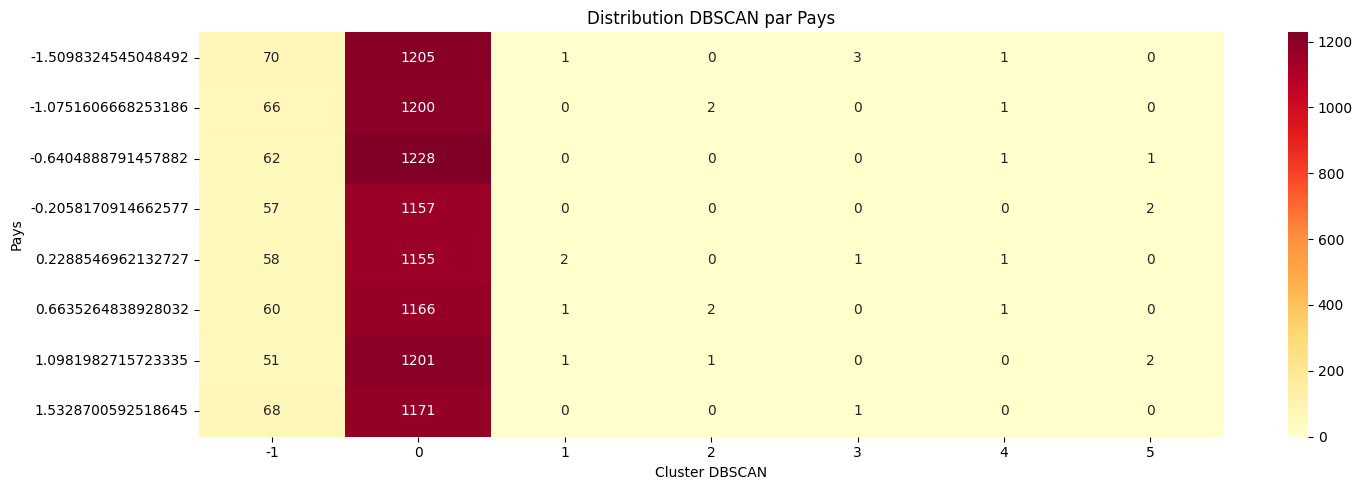

In [91]:
plt.figure(figsize=(15, 5))
if n_clusters > 0:
    cluster_by_country = df.groupby(['Location', 'DBSCAN_Cluster']).size().unstack(fill_value=0)
    sns.heatmap(cluster_by_country, annot=True, fmt='d', cmap='YlOrRd')
    plt.title('Distribution DBSCAN par Pays')
    plt.xlabel('Cluster DBSCAN')
    plt.ylabel('Pays')
else:
    plt.text(0.5, 0.5, 'Aucun cluster détecté', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('Aucun Cluster DBSCAN')

plt.tight_layout()
plt.show()

# **CAH** 

In [92]:
# Vérification des colonnes requises
required = ['Location', 'Job_Title', 'Job_Growth_Rate_%']
missing = [c for c in required if c not in df_engineered.columns]
if missing:
    print(f"❌ Colonnes manquantes: {missing}")
else:
    # Création de la matrice pivot
    pivot_df = df_engineered.pivot_table(
        values='Job_Growth_Rate_%',
        index='Location',
        columns='Job_Title',
        aggfunc='mean'
    ).fillna(0)

    print(f"Pivot matrix shape (locations x jobs): {pivot_df.shape}")
    
    # Standardisation
    scaler = StandardScaler()
    pivot_scaled = scaler.fit_transform(pivot_df.values)   
    print(f"Scaled data mean: {pivot_scaled.mean():.3f}, std: {pivot_scaled.std():.3f}")
    print(f"Pays analysés : {pivot_df.index.tolist()}")


Pivot matrix shape (locations x jobs): (8, 639)
Scaled data mean: 0.000, std: 1.000
Pays analysés : ['australia', 'brazil', 'canada', 'china', 'germany', 'india', 'uk', 'usa']


C:\Users\meria\AppData\Local\Temp\ipykernel_10112\2468012182.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


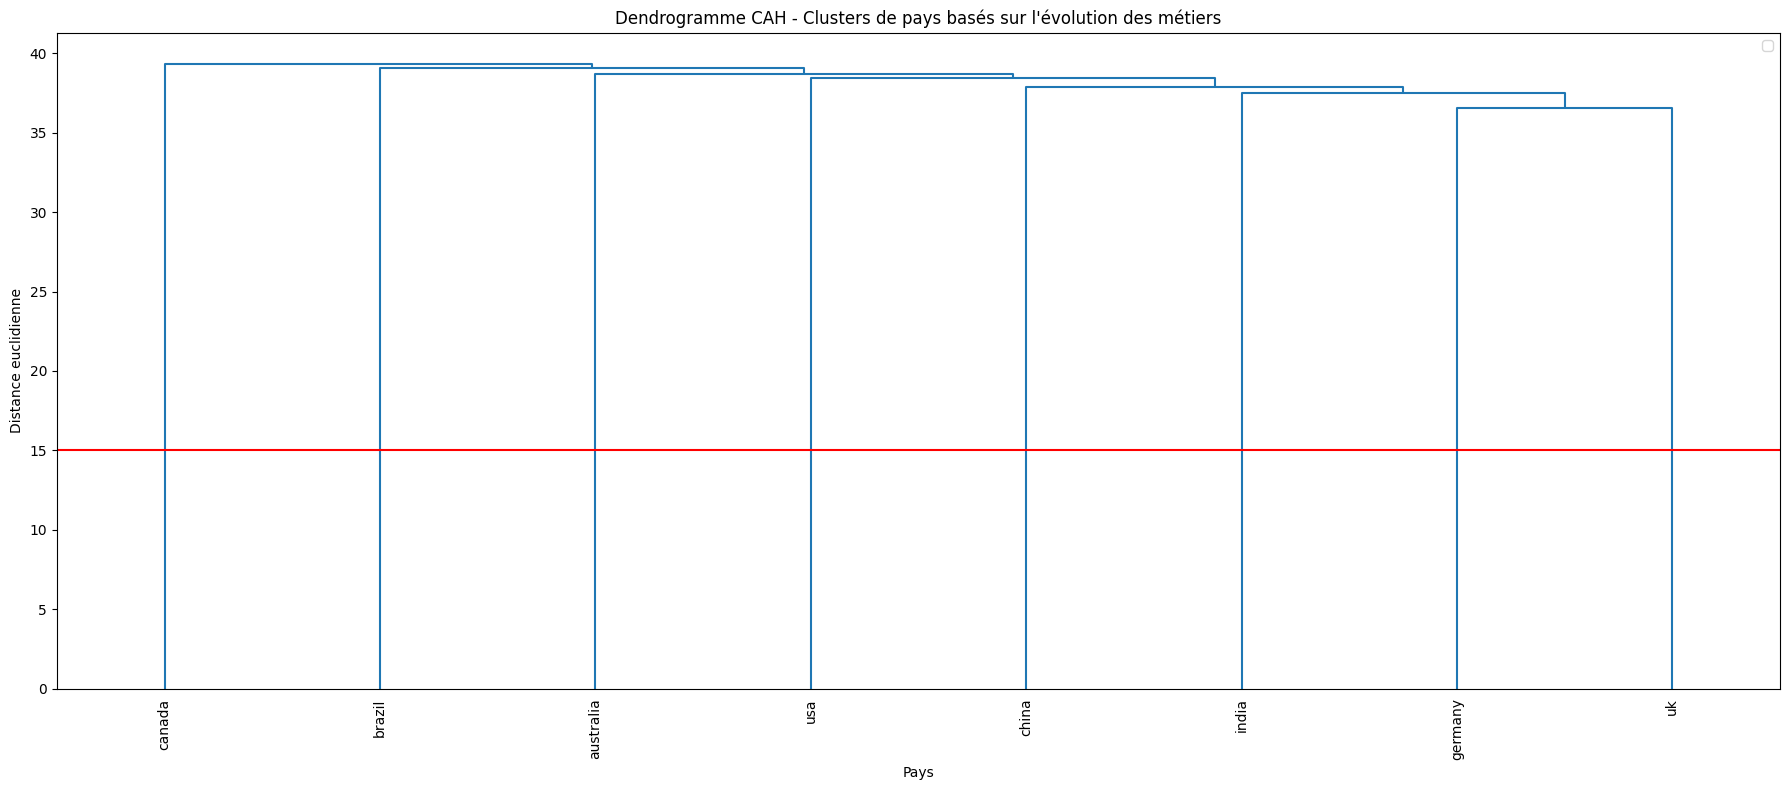

In [93]:
# Méthode 1: CAH avec scipy (pour le dendrogramme)
Z = linkage(pivot_scaled, method='ward', metric='euclidean')

# Visualisation du dendrogramme pour choisir le nombre de clusters
plt.figure(figsize=(18, 8))
dendrogram(Z,
          labels=pivot_df.index.tolist(),
          leaf_rotation=90,
          leaf_font_size=10,
          color_threshold=15)
plt.title('Dendrogramme CAH - Clusters de pays basés sur l\'évolution des métiers')
plt.axhline(y=15, color='r',)
plt.ylabel('Distance euclidienne')
plt.xlabel('Pays')
plt.legend()
plt.tight_layout()
plt.show()

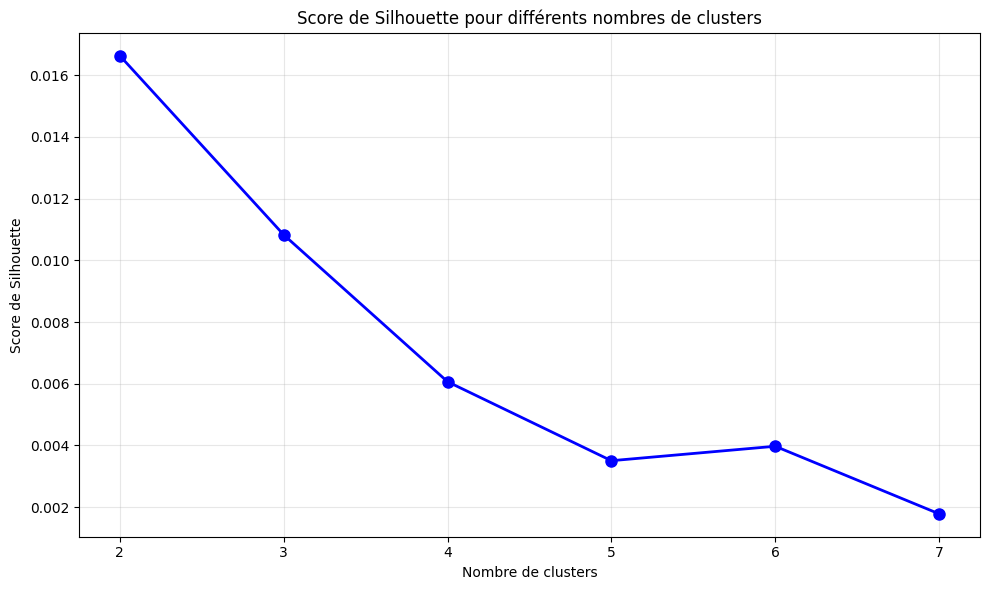

In [94]:
# Calcul du score de silhouette pour différents nombres de clusters
silhouette_scores = []
cluster_range = range(2, min(8, len(pivot_df)))  # Éviter plus de clusters que de pays

for n_clusters in cluster_range:
    # Méthode 2: CAH avec scikit-learn (plus moderne)
    hc = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage='ward'
    )
    cluster_labels = hc.fit_predict(pivot_scaled)

    if len(set(cluster_labels)) > 1:  # Éviter erreur si un seul cluster
        score = silhouette_score(pivot_scaled, cluster_labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

# Visualisation des scores de silhouette
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.title('Score de Silhouette pour différents nombres de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de Silhouette')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [95]:
# Choix du nombre optimal de clusters
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f"Nombre optimal de clusters (selon silhouette) : {optimal_clusters}")

# Utilisation du nombre optimal ou d'une valeur fixe selon le contexte
num_clusters = optimal_clusters  


Nombre optimal de clusters (selon silhouette) : 2


In [96]:
hc_final = AgglomerativeClustering(
    n_clusters=num_clusters,
    metric='euclidean',
    linkage='ward'
)
clusters = hc_final.fit_predict(pivot_scaled)
pivot_df['Cluster'] = clusters

for cluster_num in range(num_clusters):
    countries_in_cluster = pivot_df[pivot_df['Cluster'] == cluster_num].index.tolist()
    print(f"Cluster {cluster_num}: {countries_in_cluster}")

def analyze_cluster_variations(cluster_matrix, cluster_num):
    cluster_means = cluster_matrix.mean(axis=0).sort_values(ascending=False)
    top_increase = cluster_means.head(10)
    top_decrease = cluster_means.tail(10)
    print(f"\nCluster {cluster_num} summary ")
    print(f"Countries: {', '.join(cluster_matrix.index.tolist())}")
    print(f"Mean growth (all jobs): {cluster_means.mean():+.2f}%")
    print("\nTop increases (jobs):")
    print(top_increase.head(5))
    print("\nTop decreases (jobs):")
    print(top_decrease.head(5))
    return top_increase, top_decrease
print("\nDETAILED CLUSTER VARIATIONS")
for c in range(num_clusters):
    cluster_data = pivot_df[pivot_df['Cluster'] == c].drop(columns='Cluster')
    analyze_cluster_variations(cluster_data, c)

Cluster 0: ['australia', 'brazil', 'china', 'germany', 'india', 'uk', 'usa']
Cluster 1: ['canada']

DETAILED CLUSTER VARIATIONS

Cluster 0 summary 
Countries: australia, brazil, china, germany, india, uk, usa
Mean growth (all jobs): +125.42%

Top increases (jobs):
Job_Title
academic librarian                    1214.092298
corporate investment banker           1184.816774
tourist information centre manager     981.561711
aid worker                             919.501330
radiographer, therapeutic              884.943194
dtype: float64

Top decreases (jobs):
Job_Title
adult guidance worker           -24.206326
commissioning editor            -25.984433
market researcher               -26.813907
stage manager                   -27.673421
telecommunications researcher   -28.444198
dtype: float64

Cluster 1 summary 
Countries: canada
Mean growth (all jobs): +120.65%

Top increases (jobs):
Job_Title
scientist, biomedical       5377.528090
technical author            3038.323353
sports coach 

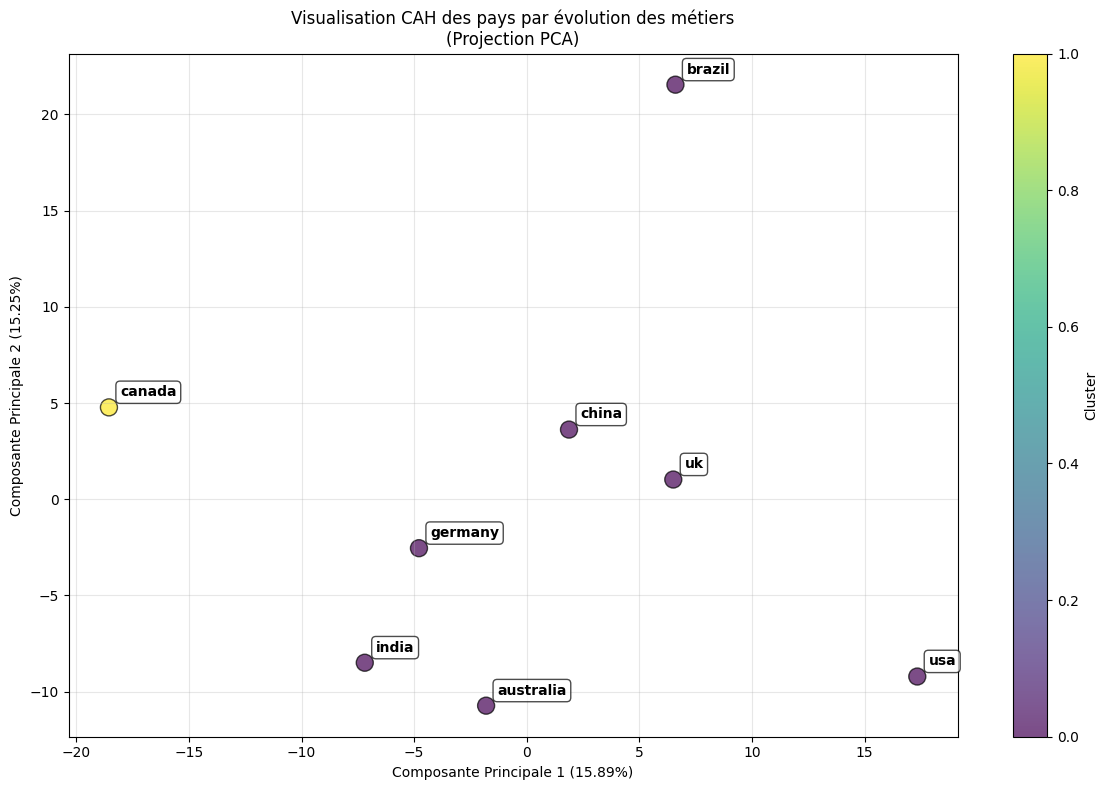

In [97]:
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
pivot_pca = pca.fit_transform(pivot_scaled)

# Créer un DataFrame pour la visualisation
pca_df = pd.DataFrame({
    'PC1': pivot_pca[:, 0],
    'PC2': pivot_pca[:, 1],
    'Cluster': clusters,
    'Country': pivot_df.index
})

plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'],
                     cmap='viridis', s=150, alpha=0.7, edgecolors='black')
# Ajouter les labels des pays
for i, country in enumerate(pca_df['Country']):
    plt.annotate(country, (pca_df['PC1'][i], pca_df['PC2'][i]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.colorbar(scatter, label='Cluster')
plt.title('Visualisation CAH des pays par évolution des métiers\n(Projection PCA)')
plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
# Calcul des statistiques globales
cluster_stats = []
for cluster_num in range(num_clusters):
    cluster_data = pivot_df[pivot_df['Cluster'] == cluster_num].drop('Cluster', axis=1)
    countries = cluster_data.index.tolist()
    mean_growth = cluster_data.values.mean()
    std_growth = cluster_data.values.std()

    cluster_stats.append({
        'Cluster': cluster_num,
        'Pays': countries,
        'Croissance Moyenne': mean_growth,
        'Variabilité': std_growth
    })

# Tri par croissance moyenne
cluster_stats_sorted = sorted(cluster_stats, key=lambda x: x['Croissance Moyenne'], reverse=True)

for i, stats in enumerate(cluster_stats_sorted, 1):
    print(f"\n{i}. Cluster {stats['Cluster']}:")
    print(f"   Pays: {', '.join(stats['Pays'])}")
    print(f"   Croissance moyenne: {stats['Croissance Moyenne']:+.1f}%")
    print(f"   Variabilité: {stats['Variabilité']:.1f}%")

# Identification des tendances globales
most_growth_cluster = cluster_stats_sorted[0]
least_growth_cluster = cluster_stats_sorted[-1]

print(f"\n CONCLUSIONS STRATÉGIQUES:")
print(f"• Le cluster le plus dynamique est le Cluster {most_growth_cluster['Cluster']} "
      f"({most_growth_cluster['Croissance Moyenne']:+.1f}%)")
print(f"• Le cluster le plus en difficulté est le Cluster {least_growth_cluster['Cluster']} "
      f"({least_growth_cluster['Croissance Moyenne']:+.1f}%)")
print(f"• Score de silhouette moyen: {silhouette_score(pivot_scaled, clusters):.3f}")

print(f"\nANALYSE TERMINÉE AVEC SUCCÈS!")
print(f"• {len(pivot_df)} pays analysés")
print(f"• {pivot_df.shape[1]-1} métiers considérés")
print(f"• {num_clusters} clusters identifiés")



1. Cluster 0:
   Pays: australia, brazil, china, germany, india, uk, usa
   Croissance moyenne: +125.4%
   Variabilité: 398.8%

2. Cluster 1:
   Pays: canada
   Croissance moyenne: +120.6%
   Variabilité: 383.7%

 CONCLUSIONS STRATÉGIQUES:
• Le cluster le plus dynamique est le Cluster 0 (+125.4%)
• Le cluster le plus en difficulté est le Cluster 1 (+120.6%)
• Score de silhouette moyen: 0.017

ANALYSE TERMINÉE AVEC SUCCÈS!
• 8 pays analysés
• 639 métiers considérés
• 2 clusters identifiés
